In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os
import joblib

import matplotlib.pyplot as plt

In [5]:
clean_df = pd.read_csv("../Data/Processed_data/features_nifty500.csv")

clean_df["Date"] = pd.to_datetime(clean_df["Date"])

clean_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return,SMA20,SMA50,EMA20,Lag1,Lag5,Volatility20,Target
0,2021-06-09,360ONE,260.813755,262.150806,249.887157,251.816010,59152.0,NaN,NaN,NaN,251.816010,NaN,NaN,NaN,257.131409
1,2021-06-10,360ONE,253.997012,260.046642,251.848943,257.131409,41084.0,0.021108,NaN,NaN,252.322238,251.816010,NaN,NaN,260.758942
2,2021-06-11,360ONE,259.443804,263.246739,256.714877,260.758942,232800.0,0.014108,NaN,NaN,253.125734,257.131409,NaN,NaN,259.619141
3,2021-06-14,360ONE,261.931602,263.027550,258.939658,259.619141,74364.0,-0.004371,NaN,NaN,253.744153,260.758942,NaN,NaN,253.821533
4,2021-06-15,360ONE,260.791773,260.791773,252.144728,253.821533,149636.0,-0.022331,NaN,NaN,253.751523,259.619141,NaN,NaN,249.843323


In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551643 entries, 0 to 551642
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          551643 non-null  datetime64[ns]
 1   Ticker        551643 non-null  object        
 2   Open          551643 non-null  float64       
 3   High          551643 non-null  float64       
 4   Low           551643 non-null  float64       
 5   Close         551643 non-null  float64       
 6   Volume        551643 non-null  float64       
 7   Daily_Return  551143 non-null  float64       
 8   SMA20         542143 non-null  float64       
 9   SMA50         527143 non-null  float64       
 10  EMA20         551643 non-null  float64       
 11  Lag1          551143 non-null  float64       
 12  Lag5          549143 non-null  float64       
 13  Volatility20  541643 non-null  float64       
 14  Target        551143 non-null  float64       
dtypes: datetime64[ns]

In [7]:
clean_df[["Ticker", "Date", "Close", "Target"]].head(10)

,Ticker,Date,Close,Target
0,360ONE,2021-06-09,251.816010,257.131409
1,360ONE,2021-06-10,257.131409,260.758942
2,360ONE,2021-06-11,260.758942,259.619141
3,360ONE,2021-06-14,259.619141,253.821533
4,360ONE,2021-06-15,253.821533,249.843323
5,360ONE,2021-06-16,249.843323,248.100723
6,360ONE,2021-06-17,248.100723,246.884247
7,360ONE,2021-06-18,246.884247,246.336227
8,360ONE,2021-06-21,246.336227,253.339340
9,360ONE,2021-06-22,253.339340,249.941940


In [8]:
model_df = clean_df.dropna().copy()

model_df.shape

(526643, 15)

Select Features (X)

In [9]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "SMA20",
    "SMA50"
]

X = model_df[features]

X.head()

,Open,High,Low,Volume,SMA20,SMA50
49,352.434792,362.169868,346.519797,395400.0,324.733131,287.261319
50,347.729678,354.003151,334.813038,273612.0,326.402046,288.987132
51,337.871386,343.831181,330.735315,260212.0,328.607704,290.510742
52,340.111869,351.930645,332.762933,162592.0,331.333055,292.157622
53,347.259137,347.281537,333.838381,113924.0,333.839395,293.679200


Select the Target (y)

In [10]:
y = model_df["Target"]

y.head()

49    338.106628
50    333.311920
51    343.102966
52    335.698029
53    336.246948
Name: Target, dtype: float64

Split the Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (421314, 6)
Testing data : (105329, 6)


Train the Random Forest Model

In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Make Predictions

In [14]:
predictions = model.predict(X_test)

predictions[:10]

array([ 662.85476112,  357.58830832, 1444.20740625, 7330.72634011,
         11.49446009,  135.92277729,  520.81726656,   98.38382956,
       1430.3388424 ,  552.26557256])

Evaluate the Model

In [15]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 30.28
RMSE: 135.41
R²  : 0.9996


Visualize the Results

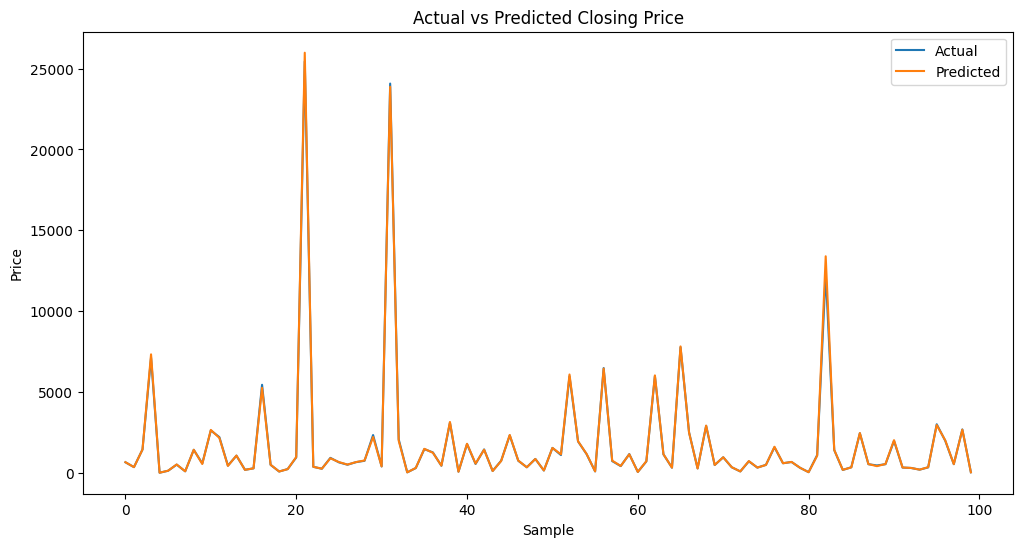

In [16]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()

plt.show()

  Feature  Importance
2     Low    0.482703
1    High    0.420113
0    Open    0.072046
4   SMA20    0.012764
5   SMA50    0.012352
3  Volume    0.000022


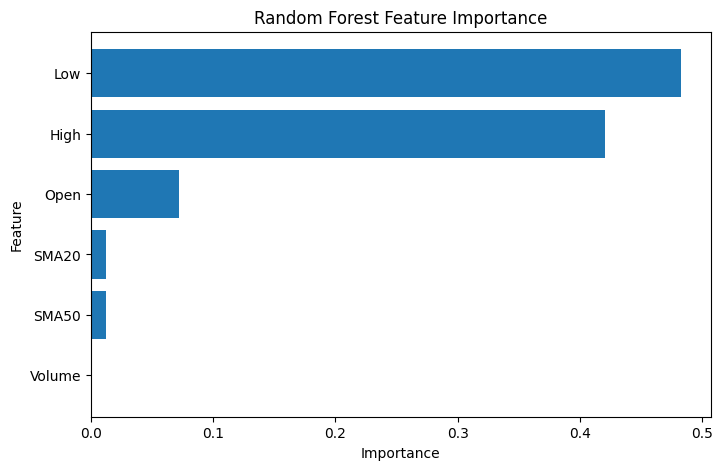

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Actual vs Predicted Scatter Plot

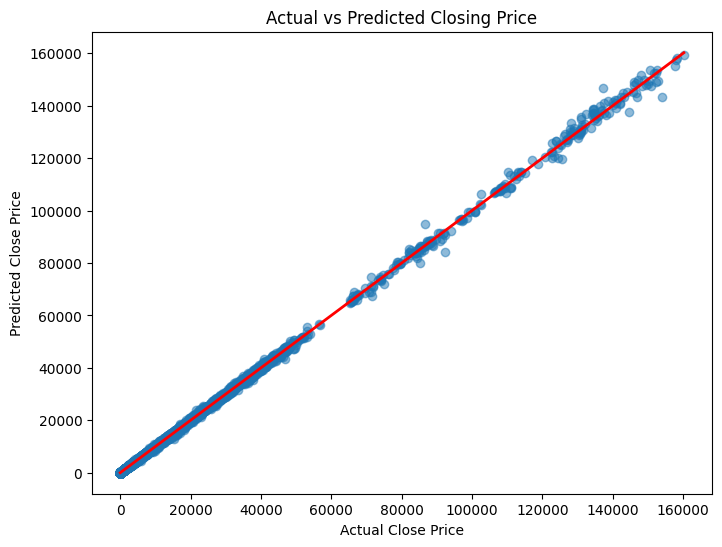

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Closing Price")

plt.show()

Residual Plot

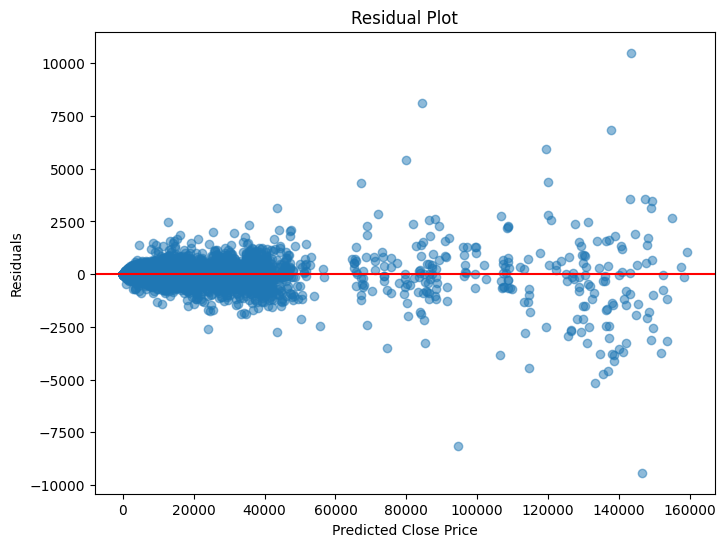

In [19]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Close Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Save the Model

In [20]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
loaded_model = joblib.load("../models/random_forest.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [22]:
import joblib

model = joblib.load("../models/random_forest.pkl")

print(model)
print(model.get_params())

RandomForestRegressor(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                      n_jobs=-1, random_state=42)
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [23]:
print("Number of trees:", len(model.estimators_))

Number of trees: 100


In [24]:
first_tree = model.estimators_[0]

print("Nodes in first tree:", first_tree.tree_.node_count)
print("Max depth:", first_tree.tree_.max_depth)

Nodes in first tree: 48369
Max depth: 20


In [25]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 30.28412354153666
RMSE: 135.41435167589543
R²  : 0.9995898369903685
